**In this chapter we will discuss more about pandas and it's usage.**

In this chapter we will discuss the some new advance concept of pandas with tips and tricks. Lets start!

In [1]:
import pandas as pd

# Load your data
df = pd.read_csv("TB_Burden_Country.csv")

# 1. See the first 5 rows to understand the structure
print(df.head())

# 2. Check total rows, columns, and data types (Are numbers stored as text?)
print(df.info())

# 3. Check basic statistics for numerical columns (mean, min, max, std)
print(df.describe())

  Country or territory name ISO 2-character country/territory code  \
0               Afghanistan                                     AF   
1               Afghanistan                                     AF   
2               Afghanistan                                     AF   
3               Afghanistan                                     AF   
4               Afghanistan                                     AF   

  ISO 3-character country/territory code  ISO numeric country/territory code  \
0                                    AFG                                   4   
1                                    AFG                                   4   
2                                    AFG                                   4   
3                                    AFG                                   4   
4                                    AFG                                   4   

  Region  Year  Estimated total population number  \
0    EMR  1990                           1173

In [2]:
# 1. Check how many missing values you have per column
print(df.isnull().sum())

# 2. Drop rows with missing values (or fill them using .fillna())
df_clean = df.dropna()

# 3. Drop exact duplicate rows
df = df.drop_duplicates()

Country or territory name                                                                            0
ISO 2-character country/territory code                                                              24
ISO 3-character country/territory code                                                               0
ISO numeric country/territory code                                                                   0
Region                                                                                               0
Year                                                                                                 0
Estimated total population number                                                                    0
Estimated prevalence of TB (all forms) per 100 000 population                                        0
Estimated prevalence of TB (all forms) per 100 000 population, low bound                            20
Estimated prevalence of TB (all forms) per 100 000 population, high bound

1. Drop the Completely Empty Columns

**Don't waste time trying to fill columns that have zero data. Drop them automatically using pandas:**

In [3]:
# Drop columns that are 100% empty
df = df.dropna(axis=1, how="all")

2. Check Exact Missing Counts for the Rest

**You have partial missing data in columns like ISO 2-character country/territory code (24 missing) and various low/high bounds. Run this to see the exact damage:**

In [4]:
# See missing values sorted from highest to lowest
missing = df.isnull().sum()
print(missing[missing > 0])

ISO 2-character country/territory code                                                        24
Estimated prevalence of TB (all forms) per 100 000 population, low bound                      20
Estimated prevalence of TB (all forms) per 100 000 population, high bound                     20
Estimated prevalence of TB (all forms), low bound                                             20
Estimated prevalence of TB (all forms), high bound                                            20
Estimated mortality of TB cases who are HIV-positive, per 100 000 population, low bound     1942
Estimated mortality of TB cases who are HIV-positive, per 100 000 population, high bound    1942
Estimated number of deaths from TB in people who are HIV-positive, low bound                1942
Estimated number of deaths from TB in people who are HIV-positive, high bound               1942
Estimated incidence (all forms) per 100 000 population, low bound                             94
Estimated incidence (all forms

3. Narrow Your Focus (Don't analyze 47 columns at once)

Global TB data across 47 columns is overwhelming. Pick a specific angle:

> Time-series trend: How has TB prevalence changed in a specific country (e.g., Pakistan) from 1990 to 2013?

> Regional comparison: Compare Region groups (like EMR, AFR, EUR) using groupby().

***Example: Extract just Pakistan's data over time to see what's happening:***

In [5]:
# Filter for Pakistan
pk_df = df[df["Country or territory name"] == "Pakistan"]
print(pk_df[["Year", "Estimated total population number", "Estimated prevalence of TB (all forms) per 100 000 population"]])

      Year  Estimated total population number  \
3421  1990                          111090879   
3422  1991                          114229172   
3423  1992                          117291344   
3424  1993                          120336722   
3425  1994                          123450933   
3426  1995                          126689577   
3427  1996                          130083700   
3428  1997                          133597492   
3429  1998                          137139290   
3430  1999                          140580398   
3431  2000                          143832014   
3432  2001                          146857081   
3433  2002                          149693684   
3434  2003                          152419974   
3435  2004                          155151394   
3436  2005                          157971415   
3437  2006                          160905794   
3438  2007                          163928329   
3439  2008                          167008083   
3440  2009          

In [6]:
# Quick hygiene check
df = df.dropna(axis=1, how="all")
print("Cleaned shape:", df.shape)

Cleaned shape: (5120, 46)


**Univariate Analysis (Understand the Core Metrics)**

> Look at individual variables to understand their spread, averages, and extreme outliers.

**Key metrics to analyze:**

> Estimated prevalence of TB (all forms) per 100 000 population

> Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population

> Case detection rate (all forms), percent

***What to do: Plot histograms and boxplots for these columns to find out if the data is heavily skewed (most countries have low TB rates while a few have massive spikes).***

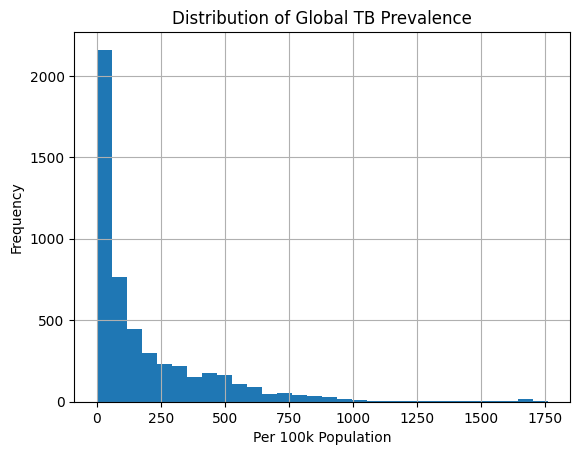

In [7]:
import matplotlib.pyplot as plt
import seaborn as seaborn_plt # or sns

# Distribution of TB prevalence per 100k
df['Estimated prevalence of TB (all forms) per 100 000 population'].hist(bins=30)
plt.title("Distribution of Global TB Prevalence")
plt.xlabel("Per 100k Population")
plt.ylabel("Frequency")
plt.show()

**Temporal Trends (How is TB changing over time?)**

1. Aggregate data globally or regionally by year to see the macro-level trajectory from 1990 to 2013.

2. What to calculate: Group by Year and find the global mean or total sum for incidence, prevalence, and mortality.

3. What to look for: Is the global burden of TB dropping, stalling, or surging over those 23 years?

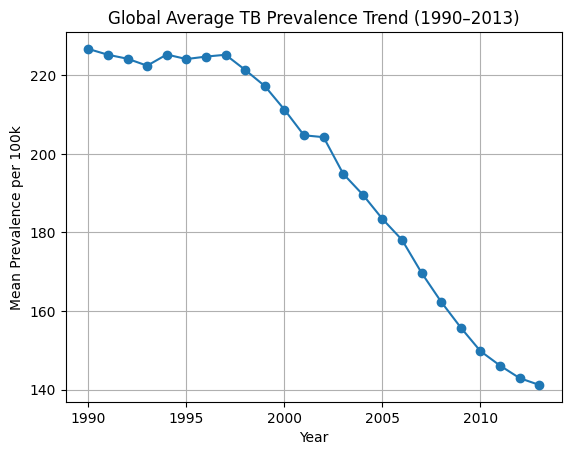

In [8]:
# Global average prevalence over time
yearly_trend = df.groupby('Year')['Estimated prevalence of TB (all forms) per 100 000 population'].mean()
yearly_trend.plot(kind='line', marker='o')
plt.title("Global Average TB Prevalence Trend (1990–2013)")
plt.ylabel("Mean Prevalence per 100k")
plt.grid(True)
plt.show()

**Regional Comparisons**

1. Your dataset includes a Region column. Use it to compare geographic blocs.

2. What to do: Group by Region and calculate the average mortality and prevalence rates.

***What to look for: Which WHO regions (e.g., EMR, AFR, EUR) carry the highest burden? Which regions made the fastest progress in driving down TB cases?***

In [9]:
# Compare average TB mortality by region
region_mortality = df.groupby('Region')['Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population'].mean().sort_values(ascending=False)
print(region_mortality)

Region
SEA    53.734881
AFR    45.890479
WPR    21.108252
EMR    16.751269
EUR     5.138681
AMR     4.858695
Name: Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population, dtype: float64


**Bivariate Analysis (Correlations & Co-infections)**

1. Find out how variables interact with each other.
2. HIV and TB Co-infection: Correlate Estimated incidence of TB cases who are HIV-positive with total TB mortality or incidence. Does high HIV prevalence drive up TB death rates?
3. Case Detection vs. Prevalence: Check if countries with higher Case detection rate have lower overall prevalence.

In [10]:
# Correlation matrix for key health indicators
cols = [
    'Estimated prevalence of TB (all forms) per 100 000 population',
    'Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population',
    'Case detection rate (all forms), percent'
]
print(df[cols].corr())

                                                    Estimated prevalence of TB (all forms) per 100 000 population  \
Estimated prevalence of TB (all forms) per 100 ...                                           1.000000               
Estimated mortality of TB cases (all forms, exc...                                           0.882110               
Case detection rate (all forms), percent                                                    -0.539735               

                                                    Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population  \
Estimated prevalence of TB (all forms) per 100 ...                                           0.882110                                   
Estimated mortality of TB cases (all forms, exc...                                           1.000000                                   
Case detection rate (all forms), percent                                                    -0.573113                   

**Targeted Country Deep-Dive (e.g., Pakistan / EMR Region)**

1. Don't just look at the whole world—ground your analysis in a specific context. Filter the data for Pakistan or your region of interest to tell a specific story.

***What to do: Extract Pakistan's timeline from 1990 to 2013, plot its prevalence and mortality curves against the global average or regional average.***

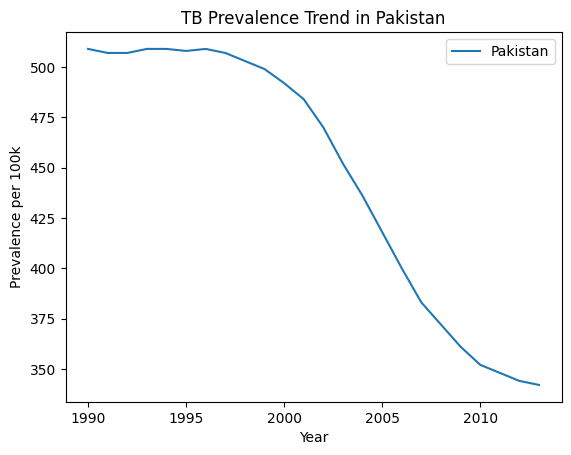

In [11]:
pakistan_df = df[df['Country or territory name'] == 'Pakistan']

plt.plot(pakistan_df['Year'], pakistan_df['Estimated prevalence of TB (all forms) per 100 000 population'], label='Pakistan')
plt.title("TB Prevalence Trend in Pakistan")
plt.xlabel("Year")
plt.ylabel("Prevalence per 100k")
plt.legend()
plt.show()

**Find the Highest TB Burden Countries**

***Don't guess which countries are struggling the most. Look at the data for the latest year (2013) to see who has the highest prevalence rate per 100k:***

In [3]:
# Filter for the latest year available (2013)
latest_year = df[df['Year'] == 2013]

# Sort by highest TB prevalence
top_tb_countries = latest_year.sort_values(
    by='Estimated prevalence of TB (all forms) per 100 000 population', 
    ascending=False
).head(10)

print(top_tb_countries[['Country or territory name', 'Estimated prevalence of TB (all forms) per 100 000 population']])

     Country or territory name  \
4339                 Swaziland   
1399                  Djibouti   
4495               Timor-Leste   
2431                  Kiribati   
843                   Cambodia   
4216              South Africa   
3112                   Namibia   
2575                   Lesotho   
1735                     Gabon   
3064                Mozambique   

      Estimated prevalence of TB (all forms) per 100 000 population  
4339                                              945.0              
1399                                              906.0              
4495                                              802.0              
2431                                              748.0              
843                                               715.0              
4216                                              715.0              
3112                                              651.0              
2575                                              613.0          

**Check Pakistan's Numbers Across Time**

> Since you need grounded insights, pull Pakistan's exact trend to see if things improved or worsened between 1990 and 2013:

In [4]:
pk_data = df[df['Country or territory name'] == 'Pakistan']
print(pk_data[['Year', 'Estimated total population number', 'Estimated prevalence of TB (all forms) per 100 000 population']])

      Year  Estimated total population number  \
3421  1990                          111090879   
3422  1991                          114229172   
3423  1992                          117291344   
3424  1993                          120336722   
3425  1994                          123450933   
3426  1995                          126689577   
3427  1996                          130083700   
3428  1997                          133597492   
3429  1998                          137139290   
3430  1999                          140580398   
3431  2000                          143832014   
3432  2001                          146857081   
3433  2002                          149693684   
3434  2003                          152419974   
3435  2004                          155151394   
3436  2005                          157971415   
3437  2006                          160905794   
3438  2007                          163928329   
3439  2008                          167008083   
3440  2009          

**Regional Summary Averages**

> Find out which WHO region had the highest average mortality rate:

In [5]:
regional_summary = df.groupby('Region')['Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population'].mean()
print(regional_summary)

Region
AFR    45.890479
AMR     4.858695
EMR    16.751269
EUR     5.138681
SEA    53.734881
WPR    21.108252
Name: Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population, dtype: float64


In the end we will can add some animated plots. 

**Create an Animated Scatter/Bubble Chart**

***This code will create an animated graph where each dot represents a country. When you press Play, it loops through the years from 1990 to 2013, showing how population and TB prevalence shifted over time!***

In [4]:
import sys
import subprocess

# Safely install/upgrade packages using Python's subprocess module (bypasses Windows path space issues)
subprocess.check_call ([sys.executable, "-m", "pip", "install", "--upgrade", "nbformat", "ipython", "plotly"])

print("Packages installed successfully! Now restart your Jupyter kernel.") 

***After running this, remember to restart your Jupyter kernel using the circular arrow button on your toolbar so Python registers the updates***

Packages installed successfully! Now restart your Jupyter kernel.


In [1]:
import pandas as pd
import plotly.express as px

# 1. Load your CSV file
df = pd.read_csv("TB_Burden_Country.csv")

# 2. Drop completely empty columns
df = df.dropna(axis=1, how="all")

# 3. Create the animated scatter plot
fig = px.scatter(
    df, 
    x="Estimated total population number", 
    y="Estimated prevalence of TB (all forms) per 100 000 population",
    animation_frame="Year", 
    animation_group="Country or territory name",
    size="Estimated total population number", 
    color="Region",
    hover_name="Country or territory name",
    log_x=True, 
    size_max=55,
    range_y=[0, 2000],
    title="Global TB Prevalence vs Population (Animated 1990–2013)"
)

# 4. Display the interactive animated graph
fig.show()

# Thank you for reading this chapter. I hope you enjoyed it and learned something new about EDA and pandas in Python. Happy coding!

[Follow me on linkedin:](www.linkedin.com/in/abdulrehman2002)